# LOCAL OUTLIER FACTOR

## 1.) Jednostavni pristup
sklearn.neighbors.LocalOutlierFactor

Predictions: 1 = inlier, -1 = outlier

Point   0: (  0.15,  -0.04)   pred= 1   LOF score=-0.970
Point   1: (  0.19,   0.46)   pred= 1   LOF score=-1.146
Point   2: ( -0.07,  -0.07)   pred= 1   LOF score=-1.054
Point   3: (  0.47,   0.23)   pred= 1   LOF score=-1.142
Point   4: ( -0.14,   0.16)   pred= 1   LOF score=-0.996
Point   5: ( -0.14,  -0.14)   pred= 1   LOF score=-0.961
Point   6: (  0.07,  -0.57)   pred= 1   LOF score=-1.136
Point   7: ( -0.52,  -0.17)   pred= 1   LOF score=-1.237
Point   8: ( -0.30,   0.09)   pred= 1   LOF score=-0.912
Point   9: ( -0.27,  -0.42)   pred= 1   LOF score=-1.090
Point  10: (  0.44,  -0.07)   pred= 1   LOF score=-1.200
Point  11: (  0.02,  -0.43)   pred= 1   LOF score=-0.975
Point  12: ( -0.16,   0.03)   pred= 1   LOF score=-1.057
Point  13: ( -0.35,   0.11)   pred= 1   LOF score=-0.967
Point  14: ( -0.18,  -0.09)   pred= 1   LOF score=-1.024
Point  15: ( -0.18,   0.56)   pred= 1   LOF score=-1.378
Point  16: ( -0.00,  -0.32)   pred= 1   LOF score

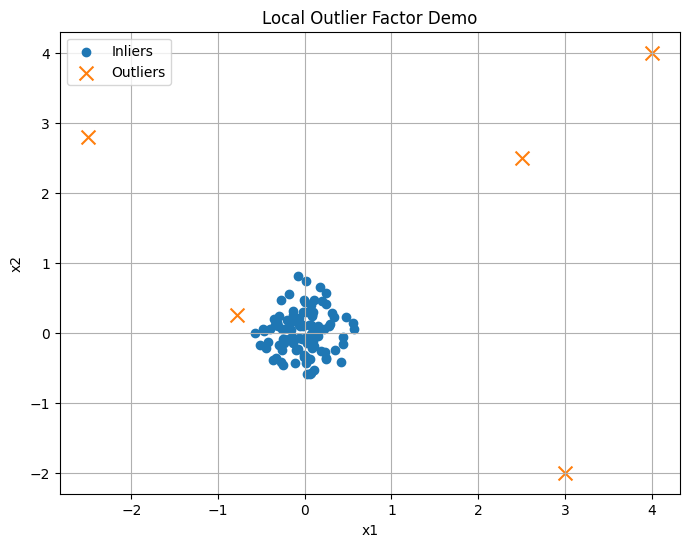

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# -----------------------------
# 1) Create data
# -----------------------------
np.random.seed(42)

# Normal points: compact cluster
X_normal = 0.3 * np.random.randn(100, 2)

# Outliers: a few points far away
X_outliers = np.array([
    [2.5, 2.5],
    [3.0, -2.0],
    [-2.5, 2.8],
    [4.0, 4.0]
])

X = np.vstack([X_normal, X_outliers])

# -----------------------------
# 2) Fit LOF
# -----------------------------
lof = LocalOutlierFactor(n_neighbors=5, contamination=0.04)
y_pred = lof.fit_predict(X)   # -1 = outlier, 1 = inlier

# LOF scores
# more negative = more abnormal
lof_scores = lof.negative_outlier_factor_

# -----------------------------
# 3) Print results
# -----------------------------
print("Predictions: 1 = inlier, -1 = outlier\n")
for i, (point, pred, score) in enumerate(zip(X, y_pred, lof_scores)):
    print(f"Point {i:3d}: ({point[0]:6.2f}, {point[1]:6.2f})   pred={pred:2d}   LOF score={score:.3f}")

# -----------------------------
# 4) Plot
# -----------------------------
inliers = X[y_pred == 1]
outliers = X[y_pred == -1]

plt.figure(figsize=(8, 6))
plt.scatter(inliers[:, 0], inliers[:, 1], label="Inliers")
plt.scatter(outliers[:, 0], outliers[:, 1], marker="x", s=100, label="Outliers")
plt.title("Local Outlier Factor Demo")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

## 2. Primjer s predavanja
Lokalna gustoća dosezljivosti (*Local reachability density*)
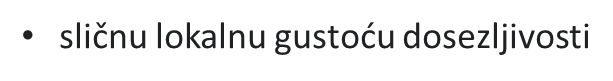
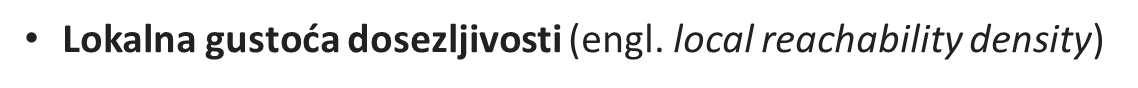


REACHABILITY DISTANCES
[[0.12  0.128 0.116]
 [0.051 0.054 0.066]
 [0.085 0.058 0.085]
 [0.053 0.066 0.063]
 [0.098 0.132 0.117]
 [0.113 0.084 0.085]
 [0.158 0.137 0.17 ]
 [0.189 0.138 0.19 ]
 [0.075 0.077 0.115]
 [0.047 0.059 0.066]
 [0.107 0.098 0.123]
 [0.284 0.221 0.237]
 [0.11  0.098 0.107]
 [0.109 0.158 0.143]
 [0.084 0.066 0.085]
 [0.113 0.158 0.131]
 [0.112 0.113 0.131]
 [0.047 0.045 0.048]
 [0.185 0.094 0.117]
 [0.116 0.106 0.128]
 [0.075 0.085 0.113]
 [0.091 0.102 0.13 ]
 [0.068 0.091 0.075]
 [0.138 0.174 0.217]
 [0.093 0.058 0.09 ]
 [0.09  0.058 0.093]
 [0.123 0.11  0.107]
 [0.143 0.098 0.109]
 [0.084 0.087 0.102]
 [0.084 0.077 0.097]
 [0.184 0.124 0.202]
 [0.237 0.26  0.274]
 [0.09  0.093 0.084]
 [0.068 0.066 0.092]
 [0.138 0.153 0.217]
 [0.113 0.098 0.098]
 [0.158 0.112 0.131]
 [0.111 0.108 0.156]
 [0.064 0.064 0.063]
 [0.059 0.06  0.066]
 [0.237 0.26  0.284]
 [0.098 0.11  0.123]
 [0.174 0.138 0.153]
 [0.062 0.065 0.106]
 [0.14  0.117 0.158]
 [0.089 0.077 0.115]
 [0.14  0.

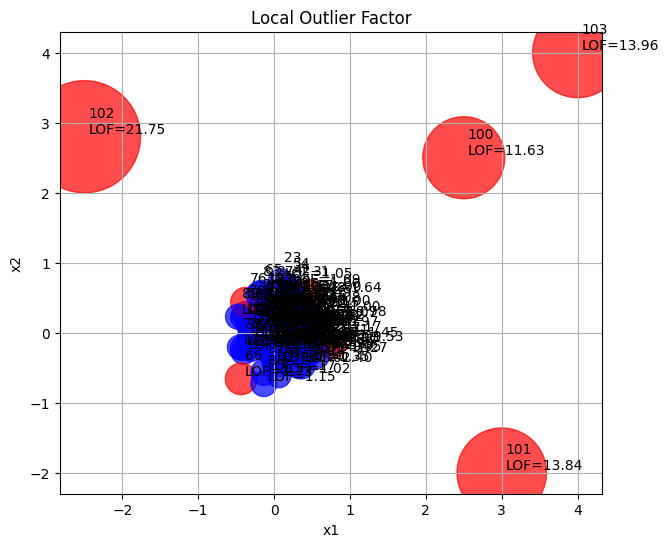

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

X_normal = 0.3 * np.random.randn(100, 2)
X_outliers = np.array([
    [2.5, 2.5],
    [3.0, -2.0],
    [-2.5, 2.8],
    [4.0, 4.0]
])

X = np.vstack([X_normal, X_outliers])

k = 3


dist = pairwise_distances(X)
neighbors = np.argsort(dist, axis=1)[:,1:k+1]   #k-nearest neighbors
k_dist = np.sort(dist, axis=1)[:,k] #k-distance

# -------------------------------------------------
# Reachability distance
# reach_dist_k(A,B) = max(k-distance(B), dist(A,B))
# -------------------------------------------------
reach_dist = np.zeros((len(X),k))

for i in range(len(X)):
    for j_idx,j in enumerate(neighbors[i]):
        reach_dist[i,j_idx] = max(k_dist[j], dist[i,j])

print("\nREACHABILITY DISTANCES")
print(np.round(reach_dist,3))


# -------------------------------------------------
# Local reachability density
# lrd(A) = 1 / average reachability distance
# -------------------------------------------------
lrd = 1 / reach_dist.mean(axis=1)

print("\nLOCAL REACHABILITY DENSITY")
for i,val in enumerate(lrd):
    print(f"Point {i}: {val:.3f}")


# -------------------------------------------------
# LOF calculation
# -------------------------------------------------
lof = np.zeros(len(X))

for i in range(len(X)):
    ratios = []
    for j in neighbors[i]:
        ratios.append(lrd[j] / lrd[i])
    lof[i] = np.mean(ratios)

print("\nLOF VALUES")
for i,val in enumerate(lof):
    print(f"Point {i}: {val:.3f}")


plt.figure(figsize=(7,6))
colors = ["red" if score > 1.5 else "blue" for score in lof]

# size proportional to LOF
sizes = 300 * lof

plt.scatter(X[:,0], X[:,1], c=colors, s=sizes, alpha=0.7)

for i,(x,y) in enumerate(X):
    plt.text(x+0.05, y+0.05, f"{i}\nLOF={lof[i]:.2f}")

plt.title("Local Outlier Factor")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)

plt.show()